In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Advertising Dataset – Sales Prediction

Business Scenario

A consumer goods company uses TV, Radio, and Newspaper advertising. The goal is to understand how these channels influence sales and predict sales for a future advertising budget.

Features: TV, Radio, Newspaper

Target: Sales

Model: Multiple Linear Regression

In [2]:
from google.colab import files

uploaded = files.upload()

Saving advertising.csv to advertising (1).csv


2. Load the Dataset
Place Advertising.csv in the same folder as this notebook. The included CSV is the standard 200-row Advertising dataset.

In [5]:
df = pd.read_csv("advertising.csv")

3. Examine Columns and Basic Information


In [6]:
df = df.loc[:, ~df.columns.astype(str).str.startswith('Unnamed')]

print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [7]:
print('Columns:', list(df.columns))
print('\nData types and missing values:')
display(pd.DataFrame({'Data Type': df.dtypes, 'Missing Values': df.isnull().sum()}))
print('\nSummary statistics:')
display(df.describe())

Columns: ['TV', 'Radio', 'Newspaper', 'Sales']

Data types and missing values:


,Data Type,Missing Values
TV,float64,0
Radio,float64,0
Newspaper,float64,0
Sales,float64,0



Summary statistics:


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


4. Select Features and Target

In [8]:
features = ['TV', 'Radio', 'Newspaper']
target = 'Sales'

X = df[features]
y = df[target]

print('Input features:', features)
print('Target:', target)

Input features: ['TV', 'Radio', 'Newspaper']
Target: Sales


5. Split Data into Training and Testing Sets

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


6. Train the Multiple Linear Regression Model

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')
print('Intercept:', round(model.intercept_, 4))

coefficients = pd.DataFrame({
    'Advertising Medium': features,
    'Coefficient': model.coef_
})
display(coefficients)

Model trained successfully.
Intercept: 4.7141


,Advertising Medium,Coefficient
0,TV,0.054509
1,Radio,0.100945
2,Newspaper,0.004337


In [15]:
print(
    f'Sales = {model.intercept_:.4f} '
    f'+ ({model.coef_[0]:.4f} × TV) '
    f'+ ({model.coef_[1]:.4f} × Radio) '
    f'+ ({model.coef_[2]:.4f} × Newspaper)'
)

Sales = 4.7141 + (0.0545 × TV) + (0.1009 × Radio) + (0.0043 × Newspaper)


7. Predict Sales for Unseen Test Data

In [16]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})
comparison['Error'] = comparison['Actual Sales'] - comparison['Predicted Sales']
display(comparison.head(10))

,Actual Sales,Predicted Sales,Error
0,16.9,17.034772,-0.134772
1,22.4,20.409740,1.990260
2,21.4,23.723989,-2.323989
3,7.3,9.272785,-1.972785
4,24.7,21.682719,3.017281
5,12.6,12.569402,0.030598
6,22.3,21.081195,1.218805
7,8.4,8.690350,-0.290350
8,16.5,17.237013,-0.737013
9,16.1,16.666575,-0.566575


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

8. Evaluate Prediction Error

In [19]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'R-squared (R²): {r2:.4f}')

Mean Absolute Error (MAE): 1.2748
Root Mean Squared Error (RMSE): 1.7052
R-squared (R²): 0.9059


9. Predict Sales for the Planned Advertising Budget
TV = 150, Radio = 20, Newspaper = 30

In [20]:
future_budget = pd.DataFrame({
    'TV': [150],
    'Radio': [20],
    'Newspaper': [30]
})

future_sales = model.predict(future_budget)[0]
print(f'Predicted sales for TV=150, Radio=20, Newspaper=30: {future_sales:.2f}')

Predicted sales for TV=150, Radio=20, Newspaper=30: 15.04


10. Interpret the Coefficients

In [21]:
coef_series = pd.Series(model.coef_, index=features)
strongest = coef_series.abs().idxmax()
weakest = coef_series.abs().idxmin()

print('Coefficients:')
for medium, coef in coef_series.items():
    print(f'{medium}: {coef:.4f}')

print(f'\nStrongest impact based on coefficient magnitude: {strongest}')
print(f'Least impact based on coefficient magnitude: {weakest}')

print('\nNote: Coefficients are measured in the dataset\'s original units. For a strictly scale-independent comparison, standardized coefficients can be used.')

Coefficients:
TV: 0.0545
Radio: 0.1009
Newspaper: 0.0043

Strongest impact based on coefficient magnitude: Radio
Least impact based on coefficient magnitude: Newspaper

Note: Coefficients are measured in the dataset's original units. For a strictly scale-independent comparison, standardized coefficients can be used.


Visualize Actual Sales vs Predicted Sales

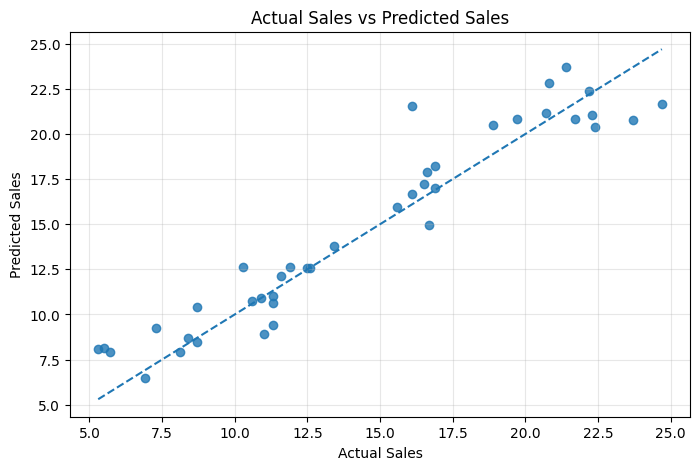

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual Sales vs Predicted Sales')
plt.grid(True, alpha=0.3)
plt.show()

12. Business Recommendation

Recommendation: Prioritize TV advertising because it generally has the strongest positive relationship with sales in this dataset. The company should also maintain an effective Radio budget and use Newspaper more selectively based on campaign performance.

13. Technical Improvement

Improvement: Try more advanced models such as Random Forest Regression or Gradient Boosting, and use cross-validation plus hyperparameter tuning. This can capture non-linear relationships and may improve prediction accuracy compared with a simple linear model.

14. Final Conclusion

Multiple Linear Regression can use TV, Radio, and Newspaper advertising spends together to predict Sales. The model is trained on historical data, evaluated on unseen test data, and used to estimate sales for a planned advertising budget. The coefficients help identify which advertising channels contribute most strongly to the model's prediction.